## Titanic EDA -keys finding
### what i found
1.**Gender Mater** -women survived much more than men
the follow the childern and women in the begining .
2.**Class Matter** - the people from class 1 survived more than the people from class 3 it is mean the money can give you best chance to survive .
3.**Age Matter** - young childern have better chane to survive that the adults.

### Conclusion
Survival on the Titanic was not random.
Age,Class and Gender they all played role.


In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv')

print(df.shape)
print(df.head())

(891, 12)
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN    

In [27]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [28]:
df.drop(columns=['Cabin'], inplace=True)

df['Age'].fillna(df['Age'].median(), inplace=True)

df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

print(df.isnull().sum())

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


C:\Users\suhai\AppData\Local\Temp\ipykernel_2372\3706977329.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace=True)
C:\Users\suhai\AppData\Local\Temp\ipykernel_2372\3706977329.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For exa

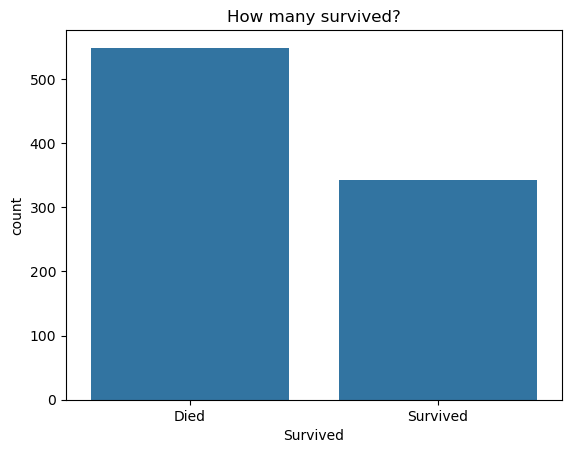

In [29]:
sns.countplot(x='Survived', data=df)
plt.title('How many survived?')
plt.xticks([0, 1], ['Died', 'Survived'])
plt.show()

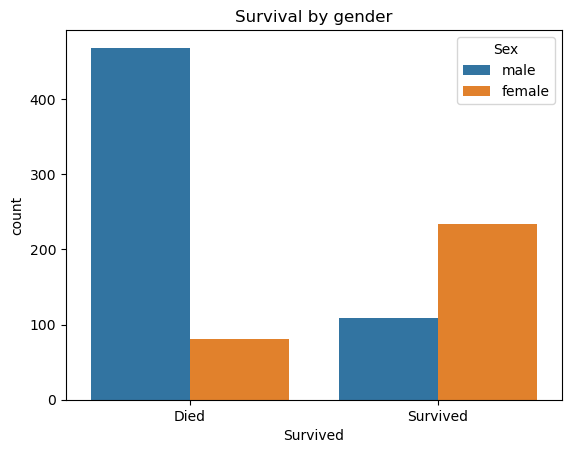

In [30]:
sns.countplot(x='Survived', hue='Sex', data=df)
plt.title('Survival by gender')
plt.xticks([0, 1], ['Died', 'Survived'])
plt.show()

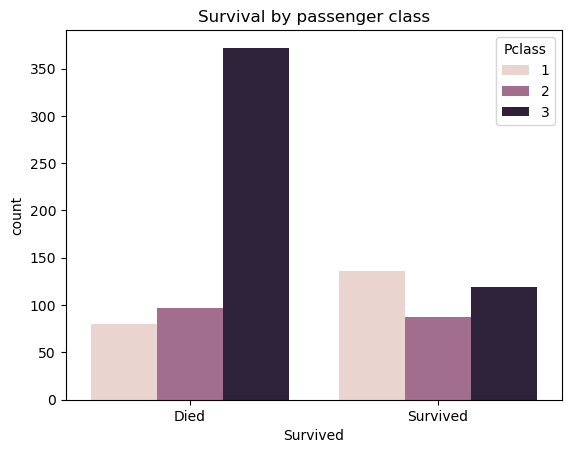

In [31]:
sns.countplot(x='Survived', hue='Pclass', data=df)
plt.title('Survival by passenger class')
plt.xticks([0, 1], ['Died', 'Survived'])
plt.show()

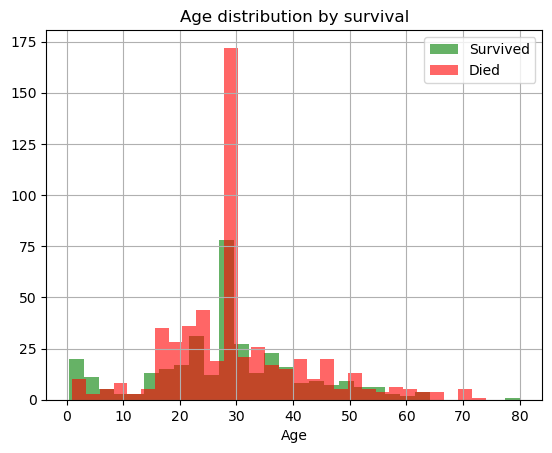

In [32]:
df[df['Survived']==1]['Age'].hist(bins=30, alpha=0.6, color='green', label='Survived')
df[df['Survived']==0]['Age'].hist(bins=30, alpha=0.6, color='red', label='Died')
plt.legend()
plt.title('Age distribution by survival')
plt.xlabel('Age')
plt.show()